<a href="https://colab.research.google.com/github/marikhakhishvili/Facial-Expression-Recognition-Challenge/blob/main/model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle wandb onnx -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 7.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
! mkdir ~/.kaggle

In [4]:
!cp /content/drive/MyDrive/cs231n/assignments/assignment4/kaggle.json ~/.kaggle/kaggle.json

In [5]:
! chmod 600 ~/.kaggle/kaggle.json

download competition data

In [6]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge

100% 285M/285M [00:01<00:00, 221MB/s]



In [7]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [8]:
import wandb
!wandb login --relogin

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


check if there are any problems with the data




In [9]:
"""
Sanity check for FER2013 pipeline.

1. Builds the smallest possible model: 1 conv layer + FC.
2. Checks initial loss is close to -ln(1/7) ~= 1.9459 (random baseline, 7 classes).
3. Trains on a fixed ~20-image subset and checks loss -> ~0 (model can memorize).
4. Logs everything to Wandb as run_0_sanity_check.

Adjust CSV_PATH / column names to match your actual train.csv (some FER2013
versions have an "emotion"+"pixels" only train.csv, others also have "Usage").
"""

import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import wandb

CSV_PATH = "train.csv"   # update to your file path
NUM_SAMPLES = 20
NUM_CLASSES = 7
NUM_STEPS = 300
LR = 1e-2
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)


class TinyFERSubset(Dataset):
    def __init__(self, csv_path, n_samples=20):
        df = pd.read_csv(csv_path)

        # If a "Usage" column exists, restrict to the training split
        if "Usage" in df.columns:
            df = df[df["Usage"] == "Training"]

        df = df.reset_index(drop=True).iloc[:n_samples]

        images = []
        for pixel_str in df["pixels"]:
            arr = np.array(pixel_str.split(), dtype=np.float32).reshape(48, 48)
            images.append(arr)

        self.images = np.stack(images) / 255.0   # (N, 48, 48), normalized
        self.labels = df["emotion"].values.astype(np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx]).unsqueeze(0).float()  # (1, 48, 48)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


class TinyNet(nn.Module):
    """Smallest reasonable model: 1 conv layer + FC."""

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)  # 48 -> 24
        self.fc = nn.Linear(8 * 24 * 24, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.flatten(1)
        return self.fc(x)


def run_sanity_check():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    wandb.init(
        project="fer2013-assignment",
        group="sanity_checks",
        name="run_0_sanity_check",
        config={
            "model": "TinyNet (1 conv + FC)",
            "num_samples": NUM_SAMPLES,
            "lr": LR,
            "num_steps": NUM_STEPS,
        },
    )

    dataset = TinyFERSubset(CSV_PATH, n_samples=NUM_SAMPLES)
    loader = DataLoader(dataset, batch_size=NUM_SAMPLES, shuffle=True)

    model = TinyNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    # --- Check 1: initial loss vs random baseline ---
    model.eval()
    with torch.no_grad():
        initial_loss = criterion(model(images), labels).item()

    expected_random_loss = -math.log(1.0 / NUM_CLASSES)
    print(f"Initial loss: {initial_loss:.4f}  (expected ~{expected_random_loss:.4f})")

    wandb.log({
        "sanity/initial_loss": initial_loss,
        "sanity/expected_random_loss": expected_random_loss,
    }, step=0)

    # --- Check 2: overfit the tiny subset ---
    model.train()
    for step in range(1, NUM_STEPS + 1):
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        acc = (logits.argmax(dim=1) == labels).float().mean().item()
        wandb.log({"sanity/loss": loss.item(), "sanity/accuracy": acc}, step=step)

        if step % 50 == 0 or step == 1:
            print(f"Step {step:4d} | loss {loss.item():.4f} | acc {acc:.2f}")

    final_loss, final_acc = loss.item(), acc
    print("\n--- Summary ---")
    print(f"Initial loss: {initial_loss:.4f} vs expected {expected_random_loss:.4f}")
    print(f"Final loss after {NUM_STEPS} steps: {final_loss:.4f}, accuracy: {final_acc:.2f}")

    if final_loss < 0.05 and final_acc > 0.95:
        print("PASS: model memorized the subset -> forward/backward pass is correct.")
    else:
        print("WARNING: did not fully overfit. Check data loading, labels, LR, or model.")

    wandb.summary.update({
        "initial_loss": initial_loss,
        "expected_random_loss": expected_random_loss,
        "final_loss": final_loss,
        "final_accuracy": final_acc,
    })
    wandb.finish()


if __name__ == "__main__":
    run_sanity_check()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: mkhak23 (mkhak23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Initial loss: 2.0955  (expected ~1.9459)
Step    1 | loss 2.0955 | acc 0.00
Step   50 | loss 0.0006 | acc 1.00
Step  100 | loss 0.0001 | acc 1.00
Step  150 | loss 0.0001 | acc 1.00
Step  200 | loss 0.0001 | acc 1.00
Step  250 | loss 0.0001 | acc 1.00
Step  300 | loss 0.0000 | acc 1.00

--- Summary ---
Initial loss: 2.0955 vs expected 1.9459
Final loss after 300 steps: 0.0000, accuracy: 1.00
PASS: model memorized the subset -> forward/backward pass is correct.


sanity/accuracy,▁▆▇▇▇███████████████████████████████████
sanity/expected_random_loss,▁
sanity/initial_loss,▁
sanity/loss,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
expected_random_loss,1.94591
final_accuracy,1
final_loss,5e-05
initial_loss,2.0955
sanity/accuracy,1
sanity/expected_random_loss,1.94591
sanity/initial_loss,2.0955


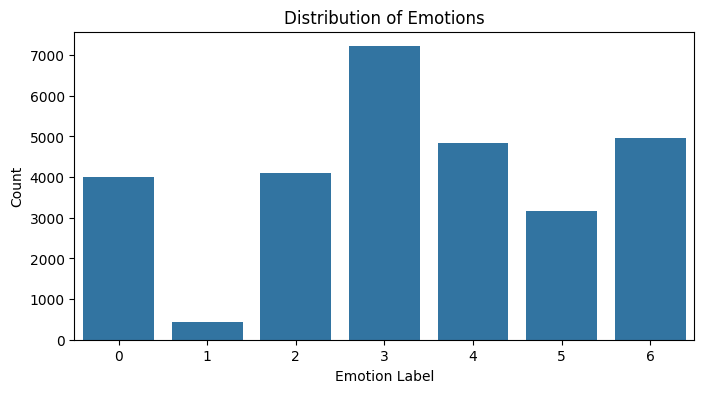

In [10]:
df = pd.read_csv('./train.csv')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Countplot of emotion distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='emotion', data=df)
plt.title('Distribution of Emotions')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.show()

In [11]:
import numpy as np

def pixels_to_image_array(pixels_str):
    """
    Converts a space-separated pixel string into a normalized
    1 x 48 x 48 NumPy array suitable for PyTorch.
    """

    # Convert string to NumPy array of floats
    pixels = np.array(pixels_str.split(), dtype=np.float32)

    # Reshape into a 48x48 image
    image = pixels.reshape(48, 48)

    # Normalize pixel values from [0, 255] to [0, 1]
    image = image / 255.0

    # Add channel dimension: (48, 48) -> (1, 48, 48)
    image = np.expand_dims(image, axis=0)

    return image

# Apply preprocessing to every image
df["pixels"] = df["pixels"].apply(pixels_to_image_array)

# Check the shape of the first image
print(df["pixels"].iloc[0].shape)
# Expected output: (1, 48, 48)

(1, 48, 48)


In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

X = np.stack(df["pixels"].values)   # shape: (N, 1, 48, 48)
y = df["emotion"].values

# First, split into training and a temporary set (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Then, split the temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [15]:
print("\nEmotion distribution in New Training Set:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nEmotion distribution in Validation Set:")
print(pd.Series(y_val).value_counts(normalize=True))

print("\nEmotion distribution in Test Set:")
print(pd.Series(y_test).value_counts(normalize=True))

print("\nEmotion distribution in New Test Set:")
print(pd.Series(y_test).value_counts(normalize=True))


Emotion distribution in New Training Set:
3    0.251294
6    0.172920
4    0.168242
2    0.142715
0    0.139182
5    0.110470
1    0.015177
Name: proportion, dtype: float64

Emotion distribution in Validation Set:
3    0.251277
6    0.173014
4    0.168137
2    0.142592
0    0.139108
5    0.110543
1    0.015327
Name: proportion, dtype: float64

Emotion distribution in Test Set:
3    0.251451
6    0.172974
4    0.168331
2    0.142791
0    0.139076
5    0.110286
1    0.015092
Name: proportion, dtype: float64

Emotion distribution in New Test Set:
3    0.251451
6    0.172974
4    0.168331
2    0.142791
0    0.139076
5    0.110286
1    0.015092
Name: proportion, dtype: float64


In [16]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [17]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 12 * 12, 128),
            nn.ReLU(),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [19]:
import wandb

wandb.init(
    project="fer2013-assignment",
    name="model1_baseline",
    config={
        "model": "BaselineCNN",
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 25,
        "optimizer": "Adam"
    }
)

config = wandb.config

In [20]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / len(loader), correct / total

In [21]:
EPOCHS = 25

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

Epoch 1/25
Train Loss: 1.6850, Train Acc: 0.3230
Val Loss: 1.5575, Val Acc: 0.3971
Epoch 2/25
Train Loss: 1.4755, Train Acc: 0.4346
Val Loss: 1.4465, Val Acc: 0.4461
Epoch 3/25
Train Loss: 1.3517, Train Acc: 0.4853
Val Loss: 1.3893, Val Acc: 0.4673
Epoch 4/25
Train Loss: 1.2581, Train Acc: 0.5239
Val Loss: 1.4122, Val Acc: 0.4621
Epoch 5/25
Train Loss: 1.1694, Train Acc: 0.5590
Val Loss: 1.3356, Val Acc: 0.4916
Epoch 6/25
Train Loss: 1.0768, Train Acc: 0.5994
Val Loss: 1.3355, Val Acc: 0.5035
Epoch 7/25
Train Loss: 0.9790, Train Acc: 0.6398
Val Loss: 1.3562, Val Acc: 0.5058
Epoch 8/25
Train Loss: 0.8762, Train Acc: 0.6838
Val Loss: 1.3964, Val Acc: 0.5046
Epoch 9/25
Train Loss: 0.7649, Train Acc: 0.7233
Val Loss: 1.4934, Val Acc: 0.4942
Epoch 10/25
Train Loss: 0.6558, Train Acc: 0.7666
Val Loss: 1.6045, Val Acc: 0.5053
Epoch 11/25
Train Loss: 0.5485, Train Acc: 0.8096
Val Loss: 1.6252, Val Acc: 0.4986
Epoch 12/25
Train Loss: 0.4479, Train Acc: 0.8464
Val Loss: 1.8704, Val Acc: 0.5098
E

In [22]:
wandb.finish()

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_acc,▁▂▃▃▃▄▄▅▅▆▆▆▇▇▇██████████
train_loss,█▇▇▆▆▅▅▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▅▇███▇█▇█▇▇▇▆▇▇▇▆▇▇▇▇▇
val_loss,▂▁▁▁▁▁▁▁▁▂▂▂▃▃▄▄▅▆▆▆▆▇▇██
epoch,25
train_acc,0.9904
train_loss,0.04629
val_acc,0.49954
val_loss,4.08017


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

In [24]:
wandb.init(
    project="fer2013-assignment",
    name="model1_lr5e-4_bs64",
    config={
        "model": "BaselineCNN",
        "lr": 5e-4,
        "batch_size": 64,
        "epochs": 10,
        "optimizer": "Adam"
    }
)

config = wandb.config

In [25]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

Epoch 1/10
Train Loss: 1.7011, Train Acc: 0.3186
Val Loss: 1.5921, Val Acc: 0.3765
Epoch 2/10
Train Loss: 1.5219, Train Acc: 0.4191
Val Loss: 1.4976, Val Acc: 0.4201
Epoch 3/10
Train Loss: 1.4242, Train Acc: 0.4547
Val Loss: 1.4445, Val Acc: 0.4477
Epoch 4/10
Train Loss: 1.3524, Train Acc: 0.4845
Val Loss: 1.4070, Val Acc: 0.4559
Epoch 5/10
Train Loss: 1.2902, Train Acc: 0.5096
Val Loss: 1.3694, Val Acc: 0.4740
Epoch 6/10
Train Loss: 1.2278, Train Acc: 0.5374
Val Loss: 1.3678, Val Acc: 0.4812
Epoch 7/10
Train Loss: 1.1716, Train Acc: 0.5598
Val Loss: 1.3458, Val Acc: 0.4891
Epoch 8/10
Train Loss: 1.1100, Train Acc: 0.5886
Val Loss: 1.3427, Val Acc: 0.5002
Epoch 9/10
Train Loss: 1.0538, Train Acc: 0.6125
Val Loss: 1.3572, Val Acc: 0.4882
Epoch 10/10
Train Loss: 0.9910, Train Acc: 0.6363
Val Loss: 1.3451, Val Acc: 0.5012


### Test Model Performance

Now, let's evaluate the model on the held-out test set to get a final performance metric.

In [26]:
test_loss, test_acc = evaluate(model, test_loader)

print(f"\nTest Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

# Log test metrics to wandb
# Ensure wandb is initialized if it's not already active from a previous run
if wandb.run is None:
    wandb.init(project="fer2013-assignment", name="test_run_evaluation")

wandb.log({
    "test_loss": test_loss,
    "test_acc": test_acc
})

wandb.finish()


Test Loss: 1.2814, Test Acc: 0.5291


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_loss,▁
train_acc,▁▃▄▅▅▆▆▇▇█
train_loss,█▆▅▅▄▃▃▂▂▁
val_acc,▁▃▅▅▆▇▇█▇█
val_loss,█▅▄▃▂▂▁▁▁▁
epoch,10
test_acc,0.52914
test_loss,1.28137
train_acc,0.63635
